In [1]:
from alldata import PresentationMapper, DataAggregator
from gaze import GazeData

In [2]:
import pandas as pd
df_pos = pd.read_csv("data/sentence_position.csv") # with pilot 2 index
df_pos.head() 

,presentation_index,part_nr,line_idx,text,top,bottom,left,right
0,0,1,0,Eva planifie un city-trip à San Francisco.,412,500,414,1506
1,0,2,0,Elle voudrait trouver un vol pas cher.,580,668,466,1454
2,1,1,0,Jeanne fait des activités touristiques.,412,500,453,1467
3,1,2,0,Elle prend beaucoup de selfies.,580,668,557,1363
4,2,1,0,Elena est de sortie en ville lorsque sa mère l...,236,324,115,1805


In [3]:
mapper2 = PresentationMapper("data/sentences.js", "data/pilot_2/sentence_order_gaze_2.csv")

gaze1 = GazeData("data/pilot_1/pilot1_gaze_2026-06-22_17-40-03 (1).csv")
gaze2 = GazeData("data/pilot_2/gaze_2.csv")
gaze3 = GazeData("data/pilot_3/gaze_2026-06-24_18-05-11.csv")

order1 = "data/pilot_1/pilot1_sentence_order_gaze_2026-06-22_17-40-03 (1).csv"
order2 = "data/pilot_2/sentence_order_gaze_2.csv"
order3 = "data/pilot_3/sentence_order_gaze_2026-06-24_18-05-11.csv"


[PresentationMapper] Initialising...
  real_order_path : data/sentences.js
  exp_order_path  : data/pilot_2/sentence_order_gaze_2.csv
  Loaded 97 sentences from real_order
  First sentence : "Il est 4 heures du matin et John est sur le point de s'endormir lorsqu'il entend des coups de feu."
  Last sentence  : "Magnus doit rejoindre son ami pour prendre un café, il décide de regarder l'heure sur son portable."
  exp_order shape : (97, 2)
  exp_order columns : ['first', 'second']
  Mapping complete. Sample rows:
 presentation_index                                                                                                                                                                                                             first  real_index
                  0                                                                                                                                                                        Eva planifie un city-trip à San Francisco.          66

In [4]:
aggregator = DataAggregator(
    gazedata=[gaze1, gaze2, gaze3],
    real_order_path="data/sentences.js",
    exp_order_paths=[order1, order2, order3],
    df_pos=df_pos,
    df_pos_participant_idx=1,  # df_pos was built from participant 2 (0-indexed = 1)
    sentence_metadata_path="data/combined_valid_sentences.xlsx"
)

# Per participant stats with real_index
df_all = aggregator.compute_gaze_fix_stats()

# Aggregated across participants
df_aggregated = aggregator.aggregate_by_sentence()


[DataAggregator] Initialising...
  Number of participants : 3
  df_pos shape           : (331, 8)
  df_pos built from participant (0-indexed): 1
[load_sentence_metadata] Loaded 97 sentences
  Columns: ['real_index', 'stimulus', 'first', 'second', 'groupUnc', 'groupRes', 'groupVal']

  groupUnc unique values (3):
    {'high unc conditions': 33, 'low unc conditions': 32, 'no unc conditions': 32}

  groupRes unique values (2):
    {'low res conditions': 33, 'high res conditions': 32}

  groupVal unique values (2):
    {'neg conditions': 49, 'pos conditions': 48}

[DataAggregator] Building mappers...

[PresentationMapper] Initialising...
  real_order_path : data/sentences.js
  exp_order_path  : data/pilot_1/pilot1_sentence_order_gaze_2026-06-22_17-40-03 (1).csv
  Loaded 97 sentences from real_order
  First sentence : "Il est 4 heures du matin et John est sur le point de s'endormir lorsqu'il entend des coups de feu."
  Last sentence  : "Magnus doit rejoindre son ami pour prendre un café, i

In [5]:
df_aggregated.head()

,real_index,mean_gaze_samples,std_gaze_samples,mean_fixations,std_fixations,n_participants,groupUnc,groupRes,groupVal
0,0,3.333333,5.773503,0.333333,0.577350,3,high unc conditions,low res conditions,neg conditions
1,1,46.333333,77.668097,0.666667,1.154701,3,high unc conditions,high res conditions,neg conditions
2,2,7.333333,7.023769,0.000000,0.000000,3,low unc conditions,high res conditions,pos conditions
3,3,63.666667,105.120566,0.000000,0.000000,3,high unc conditions,low res conditions,pos conditions
4,4,79.666667,137.986714,0.000000,0.000000,3,low unc conditions,low res conditions,pos conditions


In [6]:
# Get data for participant 0
df_p1 = df_all[df_all["participant"] == 0]

# Get data for participant 1
df_p2 = df_all[df_all["participant"] == 1]

# plots !

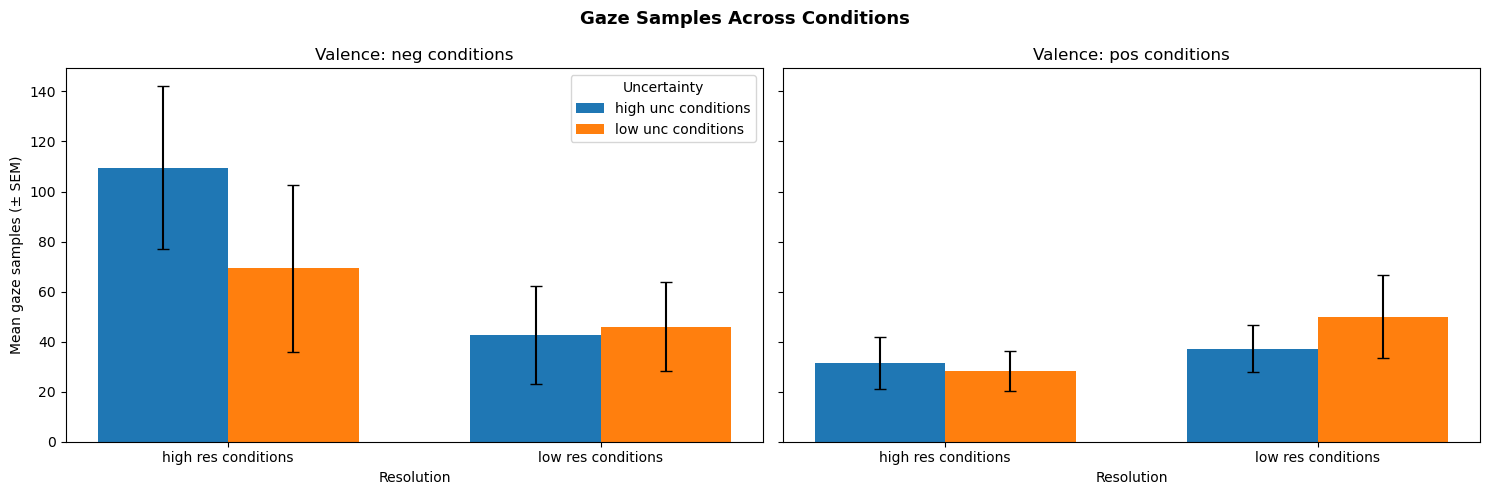

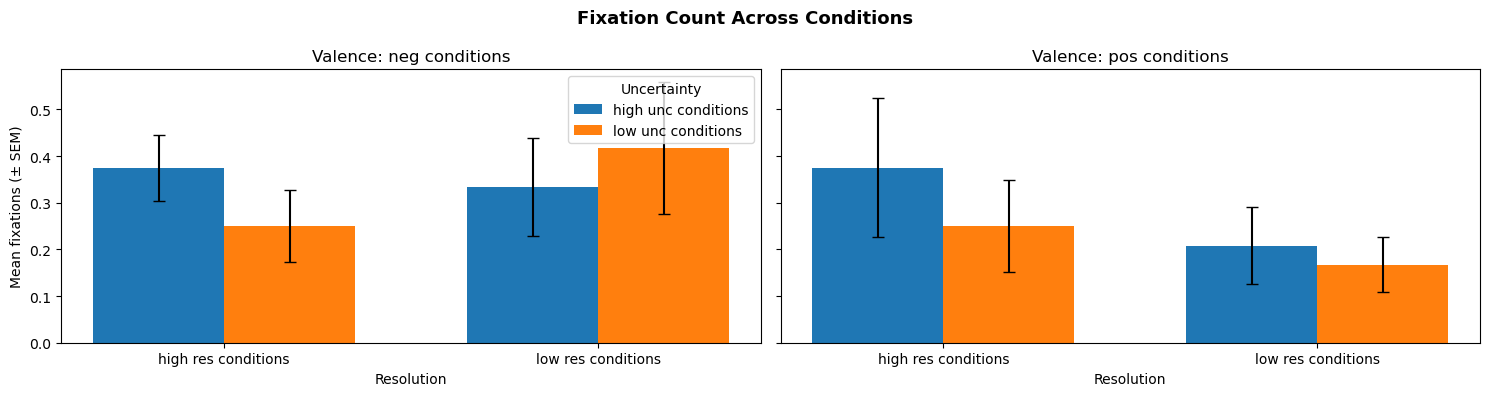

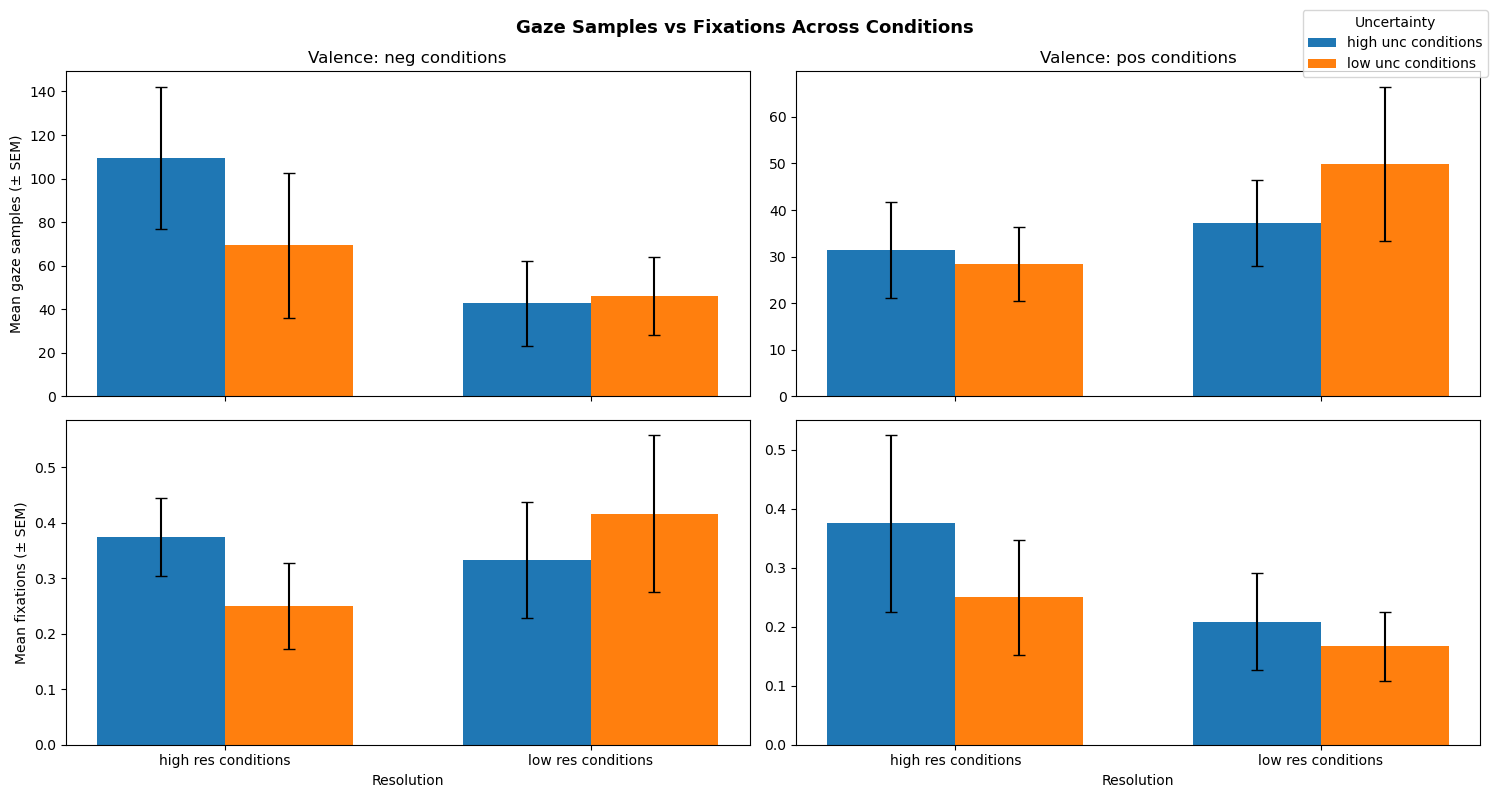

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAVING_PATH = "data/figures/"

# Use the aggregated output already computed in the notebook
# Expected columns: real_index, mean_gaze_samples, std_gaze_samples,
# mean_fixations, std_fixations, n_participants, groupUnc, groupRes, groupVal

df = df_aggregated.copy()

required_cols = [
    "real_index",
    "mean_gaze_samples",
    "std_gaze_samples",
    "mean_fixations",
    "std_fixations",
    "mean_horizontal_fixations",
    "std_horizontal_fixations",
    "n_participants",
    "groupUnc",
    "groupRes",
    "groupVal",
]
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns in df_aggregated: {missing}")

# Collapse multiple sentence-level rows to one summary row per condition combination
# so the grouped bar chart can be built without duplicate resolution labels.
df = df.dropna(subset=["groupUnc", "groupRes", "groupVal"]).copy()
for col in ["groupUnc", "groupRes", "groupVal"]:
    df[col] = df[col].astype(str)

plot_df = (
    df.groupby(["groupVal", "groupUnc", "groupRes"], as_index=False)
    .agg(
        mean_gaze_samples=("mean_gaze_samples", "mean"),
        std_gaze_samples=("mean_gaze_samples", lambda s: s.std(ddof=0)),
        mean_fixations=("mean_fixations", "mean"),
        std_fixations=("mean_fixations", lambda s: s.std(ddof=0)),
        mean_horizontal_fixations=("mean_horizontal_fixations", "mean"),
        std_horizontal_fixations=("mean_horizontal_fixations", lambda s: s.std(ddof=0)),
        n_participants=("n_participants", "count"),
    )
    .fillna({"std_gaze_samples": 0, "std_fixations": 0, "std_horizontal_fixations": 0})
)

# Make the later plotting helpers use the cleaned summary data.
df = plot_df.copy()

UNC_ORDER = sorted(df["groupUnc"].unique())
RES_ORDER = sorted(df["groupRes"].unique())
VAL_ORDER = sorted(df["groupVal"].unique())

BAR_WIDTH = 0.35
COLORS = {
    "high": "#4C72B0",
    "low": "#DD8452",
    "none": "#55A868",
}


def use_sem(std, n):
    """Convert std to SEM given n_participants."""
    return std / np.sqrt(n)


def plot_metric_by_condition(
    df,
    mean_col,
    std_col,
    title,
    ylabel,
    error_type="sem",
    figsize=(15, 4.5),
):
    """Grouped bar chart: x = groupRes, hue = groupUnc, one subplot per groupVal."""
    fig, axes = plt.subplots(1, len(VAL_ORDER), figsize=figsize, sharey=True)
    if len(VAL_ORDER) == 1:
        axes = [axes]

    x = np.arange(len(RES_ORDER))

    for ax, val in zip(axes, VAL_ORDER):
        sub = df[df["groupVal"] == val]

        for i, unc in enumerate(UNC_ORDER):
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)

            means = rows[mean_col].astype(float).values
            stds = rows[std_col].astype(float).values
            n_participants = rows["n_participants"].astype(float).values
            errors = use_sem(stds, n_participants) if error_type == "sem" else stds

            offset = (i - 0.5) * BAR_WIDTH
            ax.bar(
                x + offset,
                means,
                BAR_WIDTH,
                yerr=errors,
                capsize=4,
                label=unc,
                color=COLORS.get(unc, None),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        ax.set_title(f"Valence: {val}")
        ax.set_xlabel("Resolution")
        ax.set_ylim(bottom=0)

    axes[0].set_ylabel(ylabel)
    axes[0].legend(title="Uncertainty")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig


# Primary plot: gaze samples across conditions
fig_gaze = plot_metric_by_condition(
    df,
    mean_col="mean_gaze_samples",
    std_col="std_gaze_samples",
    title="Gaze Samples Across Conditions",
    ylabel="Mean gaze samples (± SEM)",
    error_type="sem",
    figsize=(15, 5),
)
fig_gaze.savefig(SAVING_PATH + "gaze_samples_by_condition.png", dpi=200, bbox_inches="tight")

# Secondary plot: fixations across conditions
fig_fix = plot_metric_by_condition(
    df,
    mean_col="mean_fixations",
    std_col="std_fixations",
    title="Fixation Count Across Conditions",
    ylabel="Mean fixations (± SEM)",
    error_type="sem",
    figsize=(15, 4),
)
fig_fix.savefig(SAVING_PATH + "fixations_by_condition.png", dpi=200, bbox_inches="tight")

# Tertiary plot: horizontal (within-line regression) fixations across conditions
fig_horiz = plot_metric_by_condition(
    df,
    mean_col="mean_horizontal_fixations",
    std_col="std_horizontal_fixations",
    title="Horizontal Regressions Across Conditions",
    ylabel="Mean horizontal regressions (± SEM)",
    error_type="sem",
    figsize=(15, 4),
)
fig_horiz.savefig(SAVING_PATH + "horizontal_fixations_by_condition.png", dpi=200, bbox_inches="tight")

# Combined overview for one figure
fig_combined, axes = plt.subplots(3, len(VAL_ORDER), figsize=(15, 12), sharex="col")
x = np.arange(len(RES_ORDER))

for row, (mean_col, std_col, ylabel) in enumerate(
    [
        ("mean_gaze_samples", "std_gaze_samples", "Mean gaze samples (± SEM)"),
        ("mean_fixations", "std_fixations", "Mean fixations (± SEM)"),
        ("mean_horizontal_fixations", "std_horizontal_fixations", "Mean horizontal regressions (± SEM)"),
    ]
):
    for col, val in enumerate(VAL_ORDER):
        ax = axes[row, col]
        sub = df[df["groupVal"] == val]

        for i, unc in enumerate(UNC_ORDER):
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)
            means = rows[mean_col].astype(float).values
            stds = rows[std_col].astype(float).values
            n_participants = rows["n_participants"].astype(float).values
            errors = use_sem(stds, n_participants)
            offset = (i - 0.5) * BAR_WIDTH
            ax.bar(
                x + offset,
                means,
                BAR_WIDTH,
                yerr=errors,
                capsize=4,
                label=unc if row == 0 and col == 0 else None,
                color=COLORS.get(unc, None),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        ax.set_ylim(bottom=0)
        if row == 0:
            ax.set_title(f"Valence: {val}")
        if row == 2:
            ax.set_xlabel("Resolution")
        if col == 0:
            ax.set_ylabel(ylabel)

fig_combined.legend(
    *axes[0, 0].get_legend_handles_labels(),
    title="Uncertainty",
    loc="upper right",
    bbox_to_anchor=(1.0, 1.0),
)
fig_combined.suptitle(
    "Gaze Samples, Fixations, and Horizontal Regressions Across Conditions",
    fontsize=13,
    fontweight="bold",
)
fig_combined.tight_layout()
fig_combined.savefig(SAVING_PATH + "combined_gaze_fixations_horizontal_by_condition.png", dpi=200, bbox_inches="tight")

plt.show()

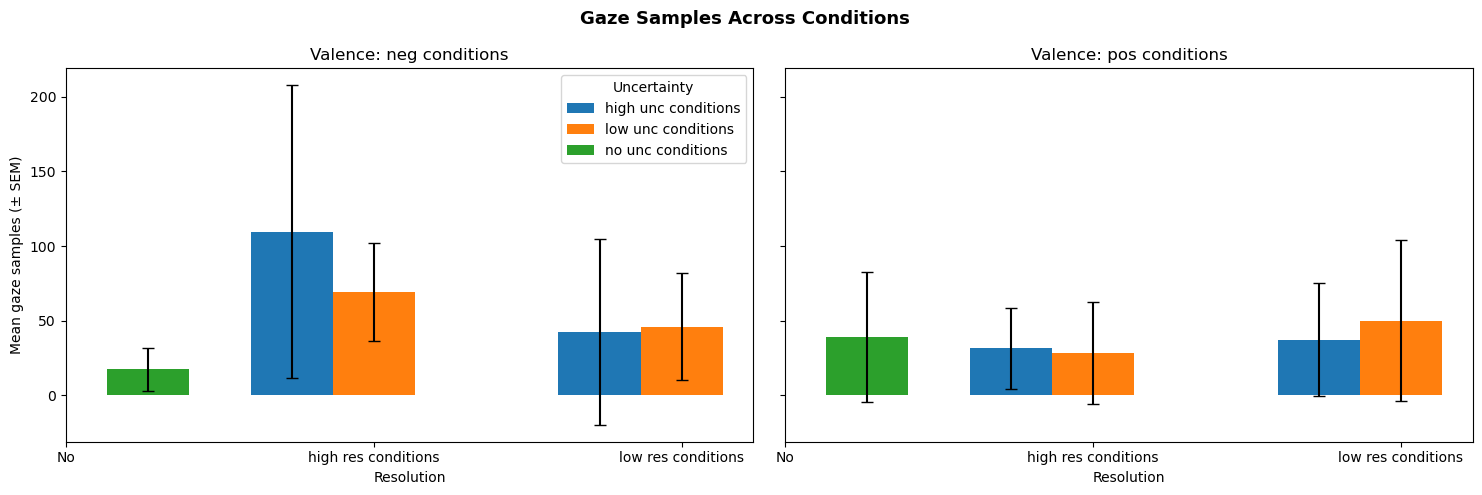

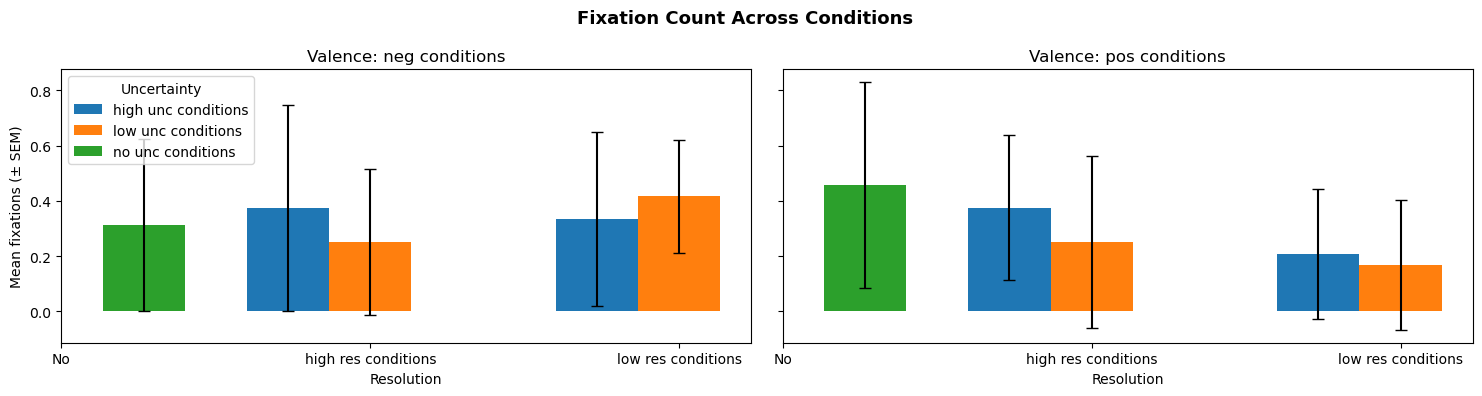

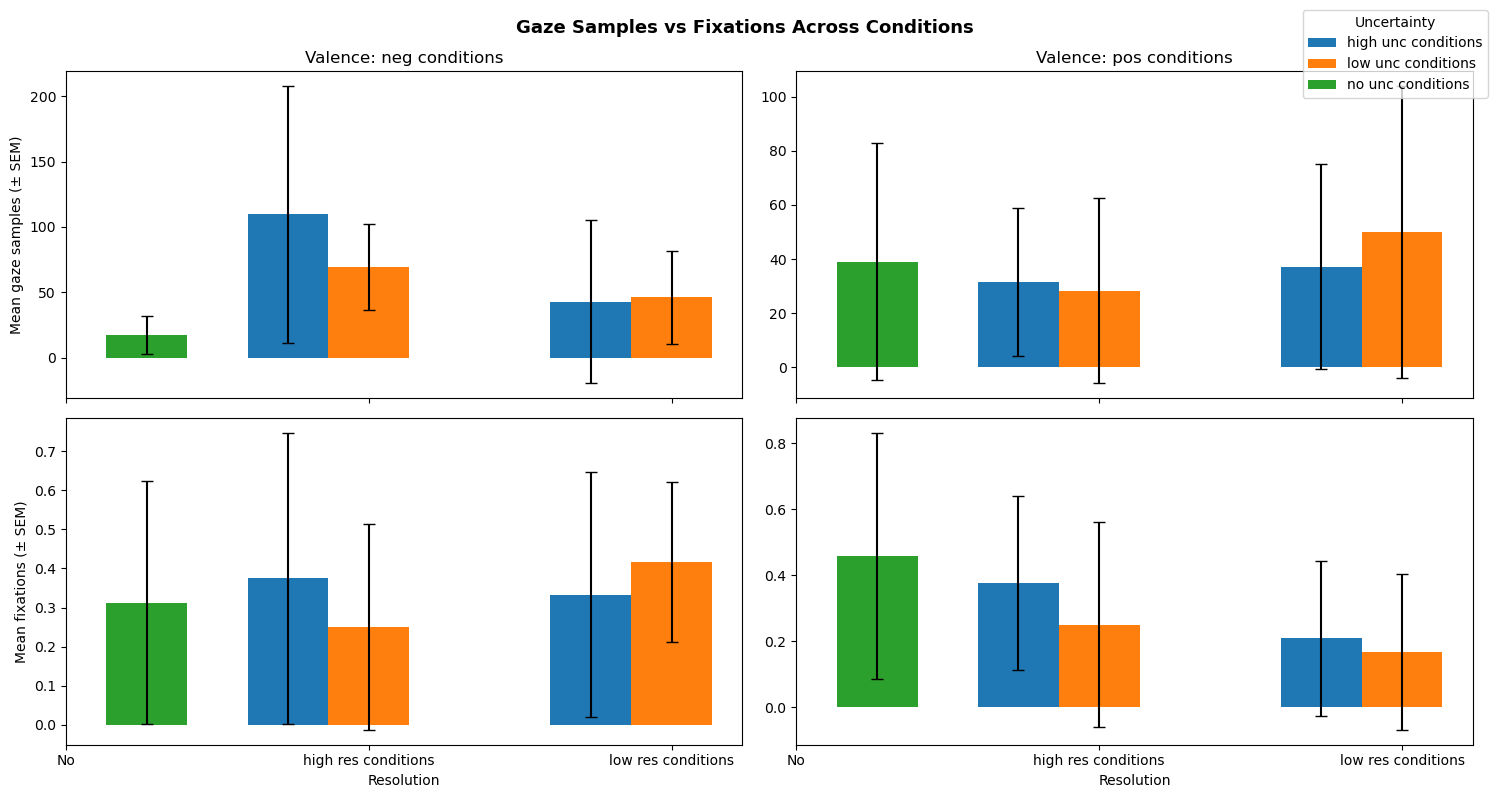

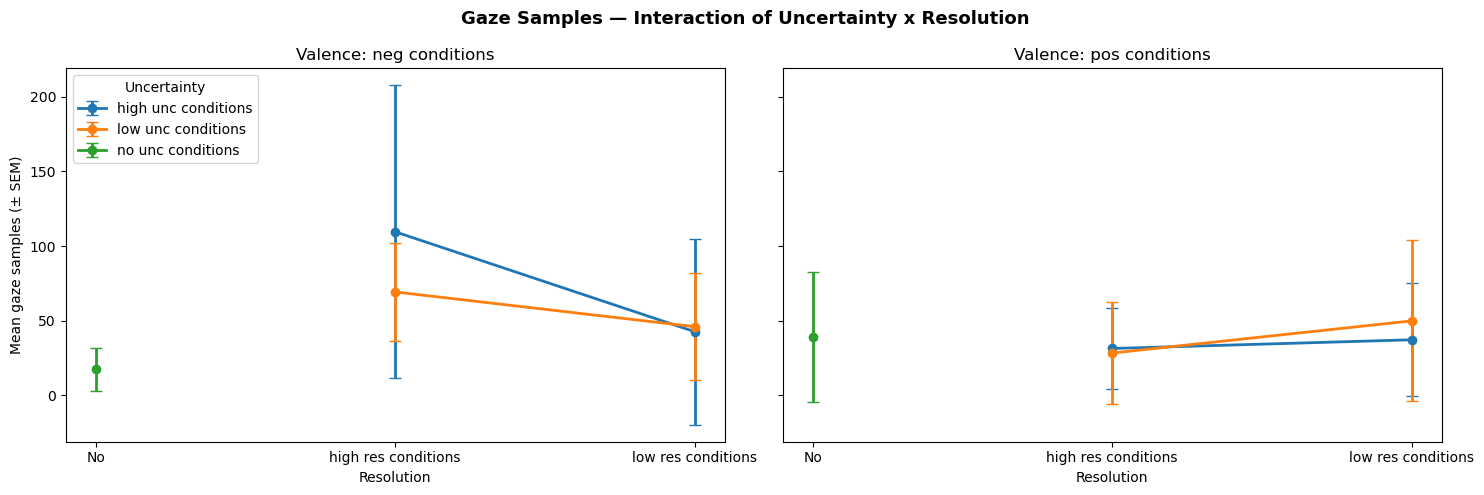

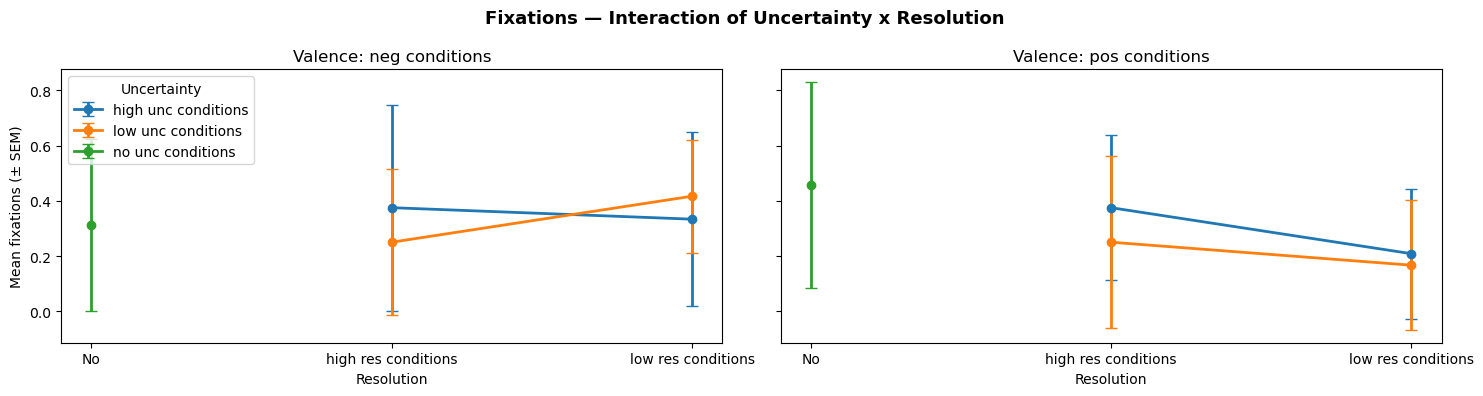

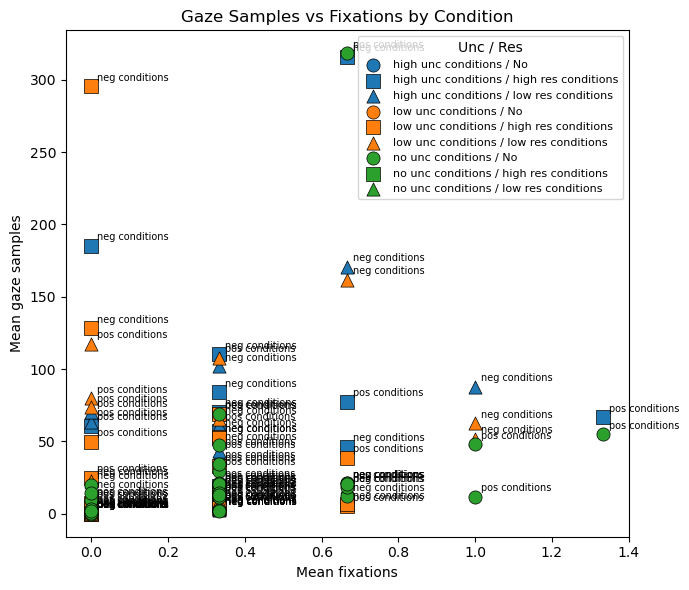

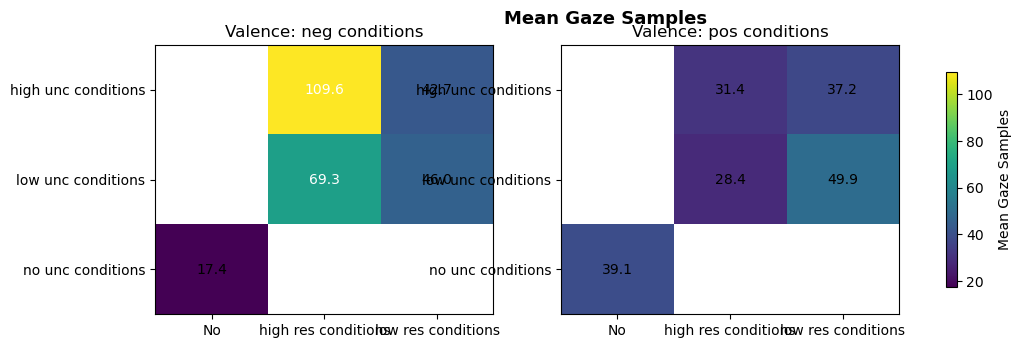

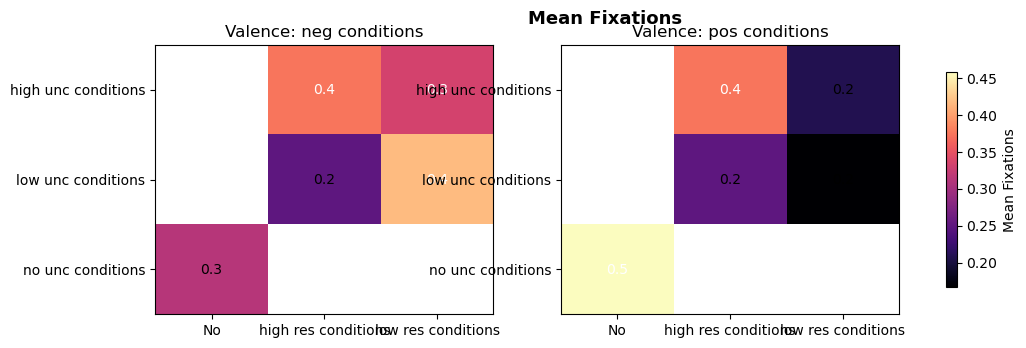

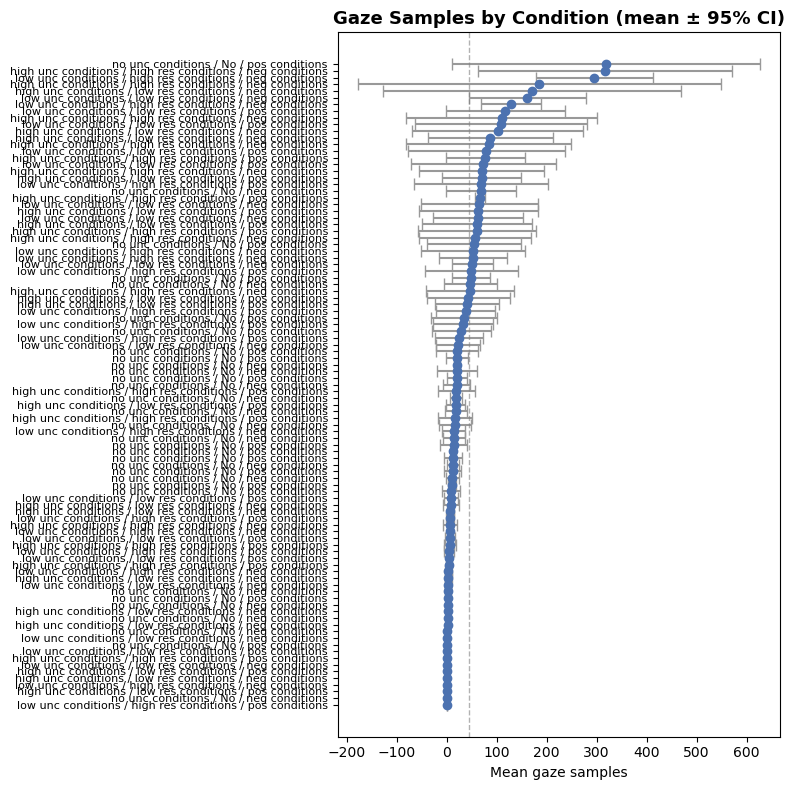

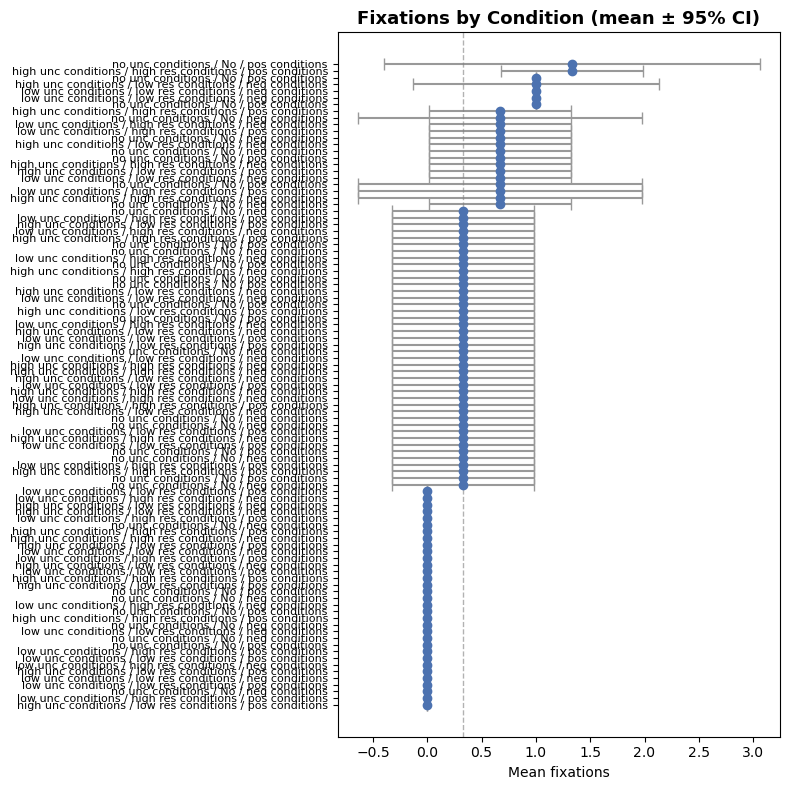

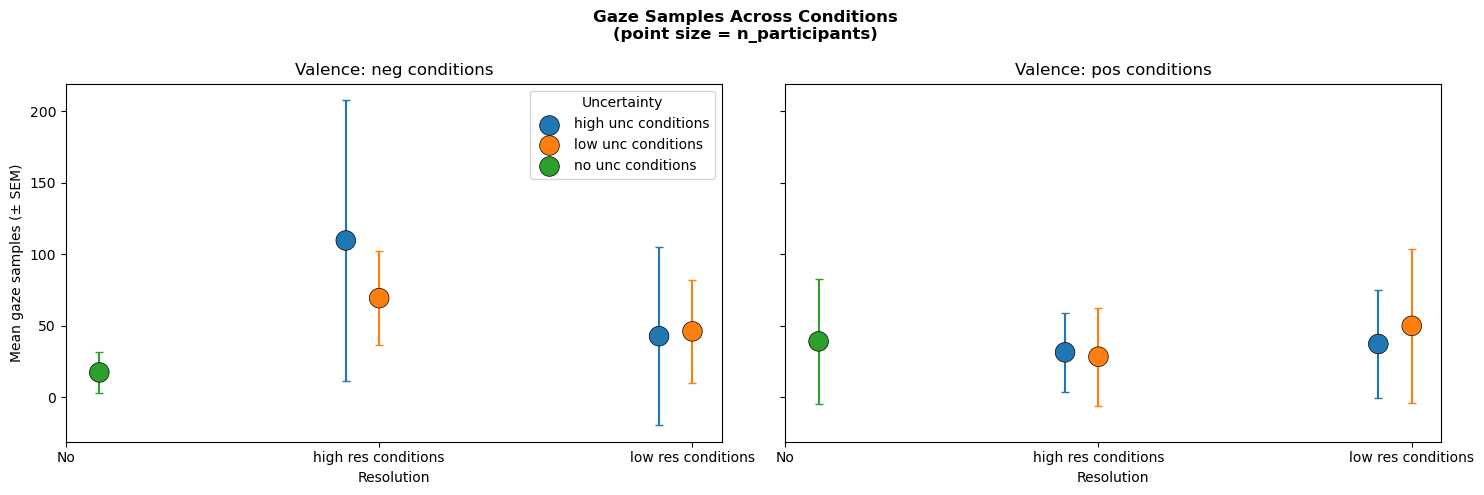

In [9]:
"""
Plot gaze samples and fixations across conditions (Uncertainty x Resolution x Valence).

Expected columns in your dataframe / CSV:
    real_index, mean_gaze_samples, std_gaze_samples,
    mean_fixations, std_fixations, n_participants,
    groupUnc, groupRes, groupVal
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. Load your data
# ---------------------------------------------------------------------------
df = df_aggregated.copy()

# ---------------------------------------------------------------------------
# Where to save all figures
# ---------------------------------------------------------------------------
SAVING_PATH = "data/figures/"
os.makedirs(SAVING_PATH, exist_ok=True)

# ---------------------------------------------------------------------------
# 2. Normalize condition labels
# ---------------------------------------------------------------------------
# groupUnc and groupRes each have 3 real levels: "High", "Low", and "No"
# (no uncertainty / no resolution manipulation). "No" is often exported as
# blank/NaN rather than the literal string "No" — normalize that here so it's
# treated as a real condition, not missing data.
for col in ["groupUnc", "groupRes"]:
    df[col] = df[col].replace(r"^\s*$", np.nan, regex=True)  # blank strings -> NaN
    df[col] = df[col].fillna("No")

# ---------------------------------------------------------------------------
# 3. Data validation — catch missing values in remaining key columns
# ---------------------------------------------------------------------------
key_cols = [
    "mean_gaze_samples", "std_gaze_samples", "mean_fixations", "std_fixations",
    "n_participants", "groupVal",
]
missing = df[key_cols].isna().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    print("Warning: missing values found in these columns:")
    print(missing.to_string())

    dropped_rows = df[df[key_cols].isna().any(axis=1)]
    print(f"\n{len(dropped_rows)} rows will be dropped (showing all of them below):\n")
    cols_to_show = [c for c in ["real_index"] + key_cols + ["groupUnc", "groupRes"] if c in df.columns]
    print(dropped_rows[cols_to_show].to_string())

    n_before = len(df)
    df = df.dropna(subset=key_cols).reset_index(drop=True)
    print(f"\nDropped {n_before - len(df)} of {n_before} rows.")

    # Quick pattern check: are the drops concentrated in one group,
    # or scattered randomly? Helps spot a systematic export issue.
    for col in ["groupUnc", "groupRes", "groupVal"]:
        if col in dropped_rows.columns and dropped_rows[col].notna().any():
            print(f"\nDropped rows by {col}:")
            print(dropped_rows[col].value_counts(dropna=False).to_string())

# ---------------------------------------------------------------------------
# 4. Config — single source of truth for grouping/order/labels
# ---------------------------------------------------------------------------
# Logical order (not alphabetical) for the No/Low/High levels. Falls back to
# alphabetical for any level name not in this map, so it still works if your
# labels differ (e.g. "None"/"Unresolved"/etc — just edit LEVEL_RANK below).
LEVEL_RANK = {"No": 0, "Low": 1, "High": 2}


def order_levels(values):
    values = sorted(set(values))
    if all(v in LEVEL_RANK for v in values):
        return sorted(values, key=lambda v: LEVEL_RANK[v])
    return values


UNC_ORDER = order_levels(df["groupUnc"].astype(str).unique())
RES_ORDER = order_levels(df["groupRes"].astype(str).unique())
VAL_ORDER = sorted(df["groupVal"].astype(str).unique())

# Colors/markers generalized to however many levels each factor actually has
# (2 or 3), rather than hardcoded for exactly 2.
_PALETTE = plt.cm.tab10.colors
COLORS = {level: _PALETTE[i % len(_PALETTE)] for i, level in enumerate(UNC_ORDER)}

_MARKER_SHAPES = ["o", "s", "^", "D", "v", "P", "X"]
MARKERS = {level: _MARKER_SHAPES[i % len(_MARKER_SHAPES)] for i, level in enumerate(RES_ORDER)}

# Bar width auto-scales to the number of Uncertainty levels so groups of
# bars stay a sensible total width regardless of whether there are 2 or 3.
N_UNC = len(UNC_ORDER)
BAR_WIDTH = 0.8 / N_UNC


def bar_offset(i, width=BAR_WIDTH, n=N_UNC):
    """x-offset for the i-th of n grouped bars/points, centered on 0."""
    return (i - (n - 1) / 2) * width


def use_sem(std, n):
    """Convert std to SEM given n_participants."""
    return std / np.sqrt(n)


def aggregate_conditions(df):
    """
    Collapse multiple rows per (groupUnc, groupRes, groupVal) — e.g. one row
    per stimulus item — into a single row per condition. Needed for any plot
    that requires exactly one row per condition (bar, line, heatmap, dot).

    Assumptions (adjust if they don't match your design):
    - mean_col is combined as an n-weighted average across items.
    - std_col is combined as sqrt(n-weighted average of variances) — this
      ignores between-item variance, so treat it as an approximation.
    - n_participants is averaged across items (assumes roughly the same
      participants contributed to each item within a condition).
    """
    def agg(g):
        w = g["n_participants"]
        return pd.Series({
            "mean_gaze_samples": np.average(g["mean_gaze_samples"], weights=w),
            "std_gaze_samples": np.sqrt(np.average(g["std_gaze_samples"] ** 2, weights=w)),
            "mean_fixations": np.average(g["mean_fixations"], weights=w),
            "std_fixations": np.sqrt(np.average(g["std_fixations"] ** 2, weights=w)),
            "n_participants": w.mean(),
            "n_items": len(g),
        })

    out = (
        df.groupby(["groupUnc", "groupRes", "groupVal"])
        .apply(agg, include_groups=False)
        .reset_index()
    )
    return out


# Condition-level dataframe for plots that need exactly one row per condition.
# Item-level `df` (with real_index) is still used for forest/scatter plots below.
df_cond = aggregate_conditions(df)


def plot_metric_by_condition(
    df, mean_col, std_col, title, ylabel, error_type="sem", figsize=(15, 4.5)
):
    """
    Grouped bar chart: x = groupRes, hue = groupUnc, one subplot per groupVal.
    """
    fig, axes = plt.subplots(1, len(VAL_ORDER), figsize=figsize, sharey=True)
    if len(VAL_ORDER) == 1:
        axes = [axes]

    x = np.arange(len(RES_ORDER))

    for ax, val in zip(axes, VAL_ORDER):
        sub = df[df["groupVal"] == val]

        for i, unc in enumerate(UNC_ORDER):
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)

            means = rows[mean_col].values
            if error_type == "sem":
                errors = use_sem(rows[std_col].values, rows["n_participants"].values)
            else:
                errors = rows[std_col].values

            offset = bar_offset(i)
            ax.bar(
                x + offset,
                means,
                BAR_WIDTH,
                yerr=errors,
                capsize=4,
                label=unc,
                color=COLORS.get(unc, None),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        ax.set_title(f"Valence: {val}")
        ax.set_xlabel("Resolution")

    axes[0].set_ylabel(ylabel)
    axes[0].legend(title="Uncertainty")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig


def plot_interaction_lines(
    df, mean_col, std_col, title, ylabel, error_type="sem", figsize=(15, 4.5)
):
    """
    Interaction line plot: x = groupRes, one line per groupUnc, one subplot per groupVal.
    Makes Uncertainty x Resolution interactions easier to spot than bars.
    """
    fig, axes = plt.subplots(1, len(VAL_ORDER), figsize=figsize, sharey=True)
    if len(VAL_ORDER) == 1:
        axes = [axes]

    x = np.arange(len(RES_ORDER))

    for ax, val in zip(axes, VAL_ORDER):
        sub = df[df["groupVal"] == val]

        for unc in UNC_ORDER:
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)
            means = rows[mean_col].values
            if error_type == "sem":
                errors = use_sem(rows[std_col].values, rows["n_participants"].values)
            else:
                errors = rows[std_col].values

            ax.errorbar(
                x, means, yerr=errors, marker="o", capsize=4, linewidth=2,
                label=unc, color=COLORS.get(unc, None),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        ax.set_title(f"Valence: {val}")
        ax.set_xlabel("Resolution")

    axes[0].set_ylabel(ylabel)
    axes[0].legend(title="Uncertainty")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig


def plot_box_violin(trial_df, metric_col, title, ylabel, kind="box", figsize=(15, 4.5)):
    """
    Box or violin plot showing within-condition distribution.
    Requires TRIAL-LEVEL data (one row per trial/participant), not the
    aggregated summary dataframe — pass a separate raw dataframe here.
    trial_df must have: metric_col, groupUnc, groupRes, groupVal.
    """
    fig, axes = plt.subplots(1, len(VAL_ORDER), figsize=figsize, sharey=True)
    if len(VAL_ORDER) == 1:
        axes = [axes]

    for ax, val in zip(axes, VAL_ORDER):
        sub = trial_df[trial_df["groupVal"] == val]
        data, labels, colors = [], [], []
        for res in RES_ORDER:
            for unc in UNC_ORDER:
                vals = sub[(sub["groupRes"] == res) & (sub["groupUnc"] == unc)][metric_col].dropna()
                data.append(vals)
                labels.append(f"{res}\n{unc}")
                colors.append(COLORS.get(unc, "#999999"))

        if kind == "box":
            bp = ax.boxplot(data, labels=labels, patch_artist=True)
            for patch, c in zip(bp["boxes"], colors):
                patch.set_facecolor(c)
        else:
            parts = ax.violinplot(data, showmeans=True)
            for pc, c in zip(parts["bodies"], colors):
                pc.set_facecolor(c)
                pc.set_alpha(0.7)
            ax.set_xticks(range(1, len(labels) + 1))
            ax.set_xticklabels(labels)

        ax.set_title(f"Valence: {val}")
        ax.tick_params(axis="x", labelsize=8)

    axes[0].set_ylabel(ylabel)
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig


def plot_scatter_gaze_vs_fixations(df, figsize=(7, 6)):
    """
    Scatter of mean_gaze_samples vs mean_fixations, one point per condition,
    colored by Uncertainty and marker-shaped by Resolution, to check whether
    the two metrics track together or diverge across conditions.
    """
    fig, ax = plt.subplots(figsize=figsize)

    for unc in UNC_ORDER:
        for res in RES_ORDER:
            sub = df[(df["groupUnc"] == unc) & (df["groupRes"] == res)]
            ax.scatter(
                sub["mean_fixations"], sub["mean_gaze_samples"],
                color=COLORS.get(unc, None), marker=MARKERS.get(res, "o"),
                s=90, edgecolor="black", linewidth=0.5,
                label=f"{unc} / {res}",
            )

    for _, row in df.iterrows():
        ax.annotate(
            row["groupVal"], (row["mean_fixations"], row["mean_gaze_samples"]),
            fontsize=7, xytext=(4, 4), textcoords="offset points",
        )

    ax.set_xlabel("Mean fixations")
    ax.set_ylabel("Mean gaze samples")
    ax.set_title("Gaze Samples vs Fixations by Condition")
    ax.legend(fontsize=8, title="Unc / Res")
    fig.tight_layout()
    return fig


def plot_heatmap(df, mean_col, title, cmap="viridis", figsize=(12, 3.5)):
    """
    Heatmap: rows = groupUnc, columns = groupRes, one tile per groupVal.
    Quick scan of which condition is highest/lowest across the full factorial.
    """
    fig, axes = plt.subplots(1, len(VAL_ORDER), figsize=figsize)
    if len(VAL_ORDER) == 1:
        axes = [axes]

    vmin, vmax = df[mean_col].min(), df[mean_col].max()

    for ax, val in zip(axes, VAL_ORDER):
        sub = df[df["groupVal"] == val]
        grid = sub.pivot(index="groupUnc", columns="groupRes", values=mean_col)
        grid = grid.reindex(index=UNC_ORDER, columns=RES_ORDER)

        im = ax.imshow(grid.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_xticks(range(len(RES_ORDER)))
        ax.set_xticklabels(RES_ORDER)
        ax.set_yticks(range(len(UNC_ORDER)))
        ax.set_yticklabels(UNC_ORDER)
        ax.set_title(f"Valence: {val}")

        for i in range(grid.shape[0]):
            for j in range(grid.shape[1]):
                v = grid.values[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                            color="white" if v > (vmin + vmax) / 2 else "black")

    fig.colorbar(im, ax=axes, shrink=0.8, label=title)
    fig.suptitle(title, fontsize=13, fontweight="bold")
    return fig


def plot_forest(df, mean_col, std_col, title, xlabel, figsize=(8, 8)):
    """
    Forest plot: one row per condition (real_index), mean +/- 95% CI.
    Compact summary of all conditions at once.
    """
    plot_df = df.copy()
    plot_df["sem"] = use_sem(plot_df[std_col], plot_df["n_participants"])
    plot_df["ci95"] = 1.96 * plot_df["sem"]
    plot_df["label"] = (
        plot_df["groupUnc"] + " / " + plot_df["groupRes"] + " / " + plot_df["groupVal"]
    )
    plot_df = plot_df.sort_values(mean_col)

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(plot_df))

    ax.errorbar(
        plot_df[mean_col], y, xerr=plot_df["ci95"],
        fmt="o", capsize=4, color="#4C72B0", ecolor="#999999",
    )
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["label"], fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axvline(plot_df[mean_col].mean(), color="gray", linestyle="--", linewidth=1, alpha=0.6)
    fig.tight_layout()
    return fig


def plot_dot_with_n(df, mean_col, std_col, title, ylabel, figsize=(15, 4.5)):
    """
    Dot plot per condition (like the bar chart layout) but point SIZE encodes
    n_participants, so sample-size differences across conditions stay visible.
    """
    fig, axes = plt.subplots(1, len(VAL_ORDER), figsize=figsize, sharey=True)
    if len(VAL_ORDER) == 1:
        axes = [axes]

    x = np.arange(len(RES_ORDER))
    n_min, n_max = df["n_participants"].min(), df["n_participants"].max()

    def scale_size(n):
        if n_max == n_min:
            return 200
        return 80 + 320 * (n - n_min) / (n_max - n_min)

    for ax, val in zip(axes, VAL_ORDER):
        sub = df[df["groupVal"] == val]

        for i, unc in enumerate(UNC_ORDER):
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)
            means = rows[mean_col].values
            errors = use_sem(rows[std_col].values, rows["n_participants"].values)
            sizes = [scale_size(n) for n in rows["n_participants"].values]

            offset = bar_offset(i, width=0.8 / N_UNC * 0.4)
            ax.errorbar(
                x + offset, means, yerr=errors, fmt="none",
                ecolor=COLORS.get(unc, None), capsize=3, zorder=1,
            )
            ax.scatter(
                x + offset, means, s=sizes, color=COLORS.get(unc, None),
                edgecolor="black", linewidth=0.5, label=unc, zorder=2,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        ax.set_title(f"Valence: {val}")
        ax.set_xlabel("Resolution")

    axes[0].set_ylabel(ylabel)
    axes[0].legend(title="Uncertainty")
    fig.suptitle(f"{title}\n(point size = n_participants)", fontsize=12, fontweight="bold")
    fig.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# 4. Primary plot: gaze samples across conditions
# ---------------------------------------------------------------------------
fig_gaze = plot_metric_by_condition(
    df_cond,
    mean_col="mean_gaze_samples",
    std_col="std_gaze_samples",
    title="Gaze Samples Across Conditions",
    ylabel="Mean gaze samples (± SEM)",
    error_type="sem",
    figsize=(15, 5),
)
fig_gaze.savefig(SAVING_PATH + "gaze_samples_by_condition.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 5. Secondary plot: fixations across conditions
# ---------------------------------------------------------------------------
fig_fix = plot_metric_by_condition(
    df_cond,
    mean_col="mean_fixations",
    std_col="std_fixations",
    title="Fixation Count Across Conditions",
    ylabel="Mean fixations (± SEM)",
    error_type="sem",
    figsize=(15, 4),
)
fig_fix.savefig(SAVING_PATH + "fixations_by_condition.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 6. Optional: combined overview (gaze on top, fixations below) for one figure
# ---------------------------------------------------------------------------
fig_combined, axes = plt.subplots(2, len(VAL_ORDER), figsize=(15, 8), sharex="col")
x = np.arange(len(RES_ORDER))

for row, (mean_col, std_col, ylabel) in enumerate(
    [
        ("mean_gaze_samples", "std_gaze_samples", "Mean gaze samples (± SEM)"),
        ("mean_fixations", "std_fixations", "Mean fixations (± SEM)"),
    ]
):
    for col, val in enumerate(VAL_ORDER):
        ax = axes[row, col]
        sub = df_cond[df_cond["groupVal"] == val]

        for i, unc in enumerate(UNC_ORDER):
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)
            means = rows[mean_col].values
            errors = use_sem(rows[std_col].values, rows["n_participants"].values)
            offset = bar_offset(i)
            ax.bar(
                x + offset, means, BAR_WIDTH, yerr=errors, capsize=4,
                label=unc if row == 0 and col == 0 else None,
                color=COLORS.get(unc, None),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        if row == 0:
            ax.set_title(f"Valence: {val}")
        if row == 1:
            ax.set_xlabel("Resolution")
        if col == 0:
            ax.set_ylabel(ylabel)

fig_combined.legend(
    *axes[0, 0].get_legend_handles_labels(), title="Uncertainty",
    loc="upper right", bbox_to_anchor=(1.0, 1.0)
)
fig_combined.suptitle("Gaze Samples vs Fixations Across Conditions", fontsize=13, fontweight="bold")
fig_combined.tight_layout()
fig_combined.savefig(SAVING_PATH + "combined_gaze_fixations_by_condition.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 7. Interaction line plots (Uncertainty x Resolution, faceted by Valence)
# ---------------------------------------------------------------------------
fig_lines_gaze = plot_interaction_lines(
    df_cond, "mean_gaze_samples", "std_gaze_samples",
    title="Gaze Samples — Interaction of Uncertainty x Resolution",
    ylabel="Mean gaze samples (± SEM)", figsize=(15, 5),
)
fig_lines_gaze.savefig(SAVING_PATH + "gaze_samples_interaction_lines.png", dpi=200, bbox_inches="tight")

fig_lines_fix = plot_interaction_lines(
    df_cond, "mean_fixations", "std_fixations",
    title="Fixations — Interaction of Uncertainty x Resolution",
    ylabel="Mean fixations (± SEM)", figsize=(15, 4),
)
fig_lines_fix.savefig(SAVING_PATH + "fixations_interaction_lines.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 8. Box/violin plots — REQUIRES trial-level data, not the aggregated summary.
# Uncomment and point at your raw per-trial dataframe if you have it.
# ---------------------------------------------------------------------------
# trial_df = pd.read_csv("your_trial_level_data.csv")
# fig_box_gaze = plot_box_violin(
#     trial_df, metric_col="gaze_samples", kind="box",
#     title="Gaze Samples Distribution by Condition", ylabel="Gaze samples",
# )
# fig_box_gaze.savefig(SAVING_PATH + "gaze_samples_boxplot.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 9. Scatter: gaze samples vs fixations, per condition
# ---------------------------------------------------------------------------
fig_scatter = plot_scatter_gaze_vs_fixations(df)
fig_scatter.savefig(SAVING_PATH + "gaze_vs_fixations_scatter.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 10. Heatmaps — full factorial at a glance
# ---------------------------------------------------------------------------
fig_heat_gaze = plot_heatmap(df_cond, "mean_gaze_samples", title="Mean Gaze Samples")
fig_heat_gaze.savefig(SAVING_PATH + "gaze_samples_heatmap.png", dpi=200, bbox_inches="tight")

fig_heat_fix = plot_heatmap(df_cond, "mean_fixations", title="Mean Fixations", cmap="magma")
fig_heat_fix.savefig(SAVING_PATH + "fixations_heatmap.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 11. Forest plots — compact all-conditions summary
# ---------------------------------------------------------------------------
fig_forest_gaze = plot_forest(
    df, "mean_gaze_samples", "std_gaze_samples",
    title="Gaze Samples by Condition (mean ± 95% CI)", xlabel="Mean gaze samples",
)
fig_forest_gaze.savefig(SAVING_PATH + "gaze_samples_forest.png", dpi=200, bbox_inches="tight")

fig_forest_fix = plot_forest(
    df, "mean_fixations", "std_fixations",
    title="Fixations by Condition (mean ± 95% CI)", xlabel="Mean fixations",
)
fig_forest_fix.savefig(SAVING_PATH + "fixations_forest.png", dpi=200, bbox_inches="tight")

# ---------------------------------------------------------------------------
# 12. Dot plots with n_participants encoded as point size
# ---------------------------------------------------------------------------
fig_dot_gaze = plot_dot_with_n(
    df_cond, "mean_gaze_samples", "std_gaze_samples",
    title="Gaze Samples Across Conditions", ylabel="Mean gaze samples (± SEM)",
    figsize=(15, 5),
)
fig_dot_gaze.savefig(SAVING_PATH + "gaze_samples_dot_with_n.png", dpi=200, bbox_inches="tight")

plt.show()